In [2]:
import os
import torch
import numpy as np
from PIL import Image
  
class EmbeddingsGenerator:
    def __init__(self,model, processor):
        self.model = model
        self.processor = processor
  
    def get_vision_embeddings(self,image:Image.Image):
        """
        Processes an image and generates vision embeddings.

        Args:
            image (Image.Image): The input PIL Image.

        Returns:
            torch.Tensor: The projected vision embeddings.
        """
        self.model.eval()
        
        # Step 1: Use the processor to get vision embeddings
        vision_inputs = self.processor.image_processor(image, return_tensors="pt")['pixel_values'].to(self.model.device, dtype=torch.bfloat16)
        # Step 2: Pass the inputs through the model's vision tower
        with torch.no_grad():
            vision_embeddings = self.model.vision_tower(vision_inputs)[0] # Get the output embeddings #go with vision_embeding
            # step3: Project vision embeddings to match text hidden size
            projected_vision_embeddings = self.model.multi_modal_projector(vision_embeddings)
        return projected_vision_embeddings
            
    def save_embeddings(self,embeddings,embeddings_path, filename):
        """
        Saves a PyTorch tensor as a NumPy .npy file.

        Args:
            embeddings (torch.Tensor): The embeddings to save.
            embeddings_path (str): The directory to save the file.
            filename (str): The name of the original image file.
        """
        # Ensure the destination directory exists
        os.makedirs(embeddings_path, exist_ok=True)
        
        # Create a new filename with the .npy extension
        npy_filename = os.path.splitext(filename)[0] + '.npy'
        
        # Construct the full file path
        file_path = os.path.join(embeddings_path, npy_filename)
        
        # Detach tensor from the graph, move to CPU, convert to NumPy array, and save
        np.save(file_path, embeddings.detach().cpu().to(torch.float32).numpy())
        print(f"Saved embeddings to: {file_path}")
        
    def create_payloads(self,filename:str,image_path:str, embeddings_path:str):
        """
        Creates a dictionary payload for an image.

        Args:
            filename (str): The name of the original image file.
            address (str): The file path to the saved embeddings.

        Returns:
            dict: The created payload.
        """
        payloads = {
            "image_filename": filename,
            "image_path": image_path,
            "embeddings_path": embeddings_path,
        }
        return payloads
        

    def run(self, source_path,embeddings_path):
        """
        Processes all images in a source directory, generates embeddings,
        saves them, and creates a list of payloads.

        Args:
            source_path (str): The directory containing input images.
            embeddings_path (str): The directory to save the generated embeddings.

        Returns:
            tuple: A tuple containing a list of mean embeddings and a list of payloads.
        """

        mean_embeddings = []
        payloads = []
        
        for filename in os.listdir(source_path):
            image_path = os.path.join(source_path,filename)
            # Ensure we only process image files
            if os.path.isfile(image_path) and filename.lower().endswith(('.png', '.jpg', '.jpeg', '.webp')):
                try:
                    # Open the image file
                    with Image.open(image_path).convert("RGB") as image:
                        vision_embeddings = self.get_vision_embeddings(image)
                        self.save_embeddings(vision_embeddings,embeddings_path,filename)
                        #
                        npy_filename = os.path.splitext(filename)[0] + '.npy'
                        embeddings_path = os.path.join(embeddings_path, npy_filename)
                        image_data = self.create_payloads(filename, image_path, embeddings_path)
                        mean_embeddings.append(torch.mean(vision_embeddings,dim =1).detach().cpu().to(torch.float32).flatten().numpy())
                        payloads.append(image_data)
                except Exception as e:
                    print(f"Could not process image {filename}: {e}")
            
        return {"vectors": mean_embeddings, "payloads": payloads}
        

In [3]:
from abc import ABC, abstractmethod
from typing import List, Any, Dict
from qdrant_client import QdrantClient, models
import numpy as np

class VectorDatabase(ABC):
    """
    Abstract Base Class for any system that manages a vector database 
    """
    @abstractmethod
    def create_collection(self) -> None:
        """
        Ensures the necessary collection/index is created or exists.
        """
        pass
        
    @abstractmethod
    def add_embeddings(self, vectors: List[List[float]], payloads: List[Dict[str, Any]]) -> None:
        """
        Adds vectors and their corresponding payloads to the database.
        
        Args:
            vectors: A list of embedding vectors.
            payloads: A list of dictionaries containing metadata for each vector.
        """
        pass
        
    @abstractmethod
    def retrieve_embeddings(self, query_vector: List[float], rescore_limit:int = 10, limit: int = 5) -> List[Any]:
        """
        Performs a similarity search using a query vector.
        
        Args:
            query_vector: The vector to search with.
            limit: The maximum number of results to return.
            
        Returns:
            A dictionary of search results including vectors and payloads.
        """
        pass
    @abstractmethod
    def  delete_collection_auto(self)-> None:
        pass




class EmbeddingsDB(VectorDatabase):
    def __init__(self, client:QdrantClient, collection_name:str,vector_dim:int=2560):
        self.collection_name = collection_name
        self.vector_dim = vector_dim
        self.client = client
        self.create_collection()         
            
    def create_collection(self):
        if not self.client.collection_exists(self.collection_name):
            self.client.create_collection(
                collection_name=self.collection_name,
                vectors_config=models.VectorParams(size=self.vector_dim, distance=models.Distance.COSINE),
                quantization_config=models.ScalarQuantization(
                    scalar=models.ScalarQuantizationConfig(
                        type=models.ScalarType.INT8,  # compress each float to 1 byte
                        quantile=0.99,
                        always_ram=True               # keep quantized copy in memory
                    ),
                ),
            )
            print(f"Collection '{self.collection_name}' created successfully.")
        else:
            print(f"Collection '{self.collection_name}' already exists.")

    # @staticmethod
    # def batched(iterable, n):
    #     iterator = iter(iterable)
    #     while batch := list(islice(iterator, n)):
    #         yield batch

    def add_embeddings(self, vectors,payloads,ids=None, batch_size:int=256):
        # upload_collection: high_level
        self.client.upload_collection(
            collection_name=self.collection_name,
            vectors=vectors,
            payload=payloads,
            ids=ids,
            batch_size=batch_size
        )
        print(f"Uploaded {len(vectors)} vectors in batches of {batch_size}.")
        
        # # upsert points: low_level
        # for batch_data in self.batched(zip(vectors, payloads), batch_size):
        #     points = []
        #     for vector, payload in batch_data:
        #         points.append(
        #             models.PointStruct(
        #                 vector=vector,
        #                 payload=payload
        #             )
        #         )

        #     # Use client.upsert() with the created PointStructs.
        #     self.client.upsert(
        #         collection_name=self.collection_name,
        #         points=points,
        #     )
        #     print(f"Uploaded a batch of {len(points)} points.")
        
        
        
    def retrieve_embeddings(self, query_vector, rescore_limit, limit):
        hits = self.client.query_points(
            collection_name = self.collection_name,
            # RESCORING -> Go to disk 
            # This takes the candidates from the prefetch and reranks them.
            # We explicitly ask for rescoring to get a more accurate score.
            # The final limit (e.g., 5) is applied here.
            query=query_vector,
            limit=limit, # Final number of results
            search_params=models.SearchParams(
                quantization=models.QuantizationSearchParams(
                rescore=True,
                ),
            ),
            # prefetch 
            # Prefetch is performed using only in-RAM data,
            # so querying even large amount of data is fast
            prefetch=models.Prefetch(
                query=query_vector,
                limit=rescore_limit,
                params=models.SearchParams(
                    quantization=models.QuantizationSearchParams(
                        # Avoid rescoring in prefetch
                        # We should do it explicitly on the second stage
                        rescore=False,
                    ),
                )
            ),



            ).points
        
        for hit in hits:
            print(hit.payload, hit.score)
        return hits

    def delete_collection_auto(self):
        self.client.delete_collection(collection_name=self.collection_name)
        print(f"Collection '{self.collection_name}' deleted successfully.")


# Creat vision embeddings and save in DB

In [26]:
import torch
from PIL import Image
from transformers import AutoProcessor, AutoModelForCausalLM
from huggingface_hub import login

def create_and_save_embeddings(get_embeddings:EmbeddingsGenerator, image_path:str,embeddings_path:str,embeddings_db:EmbeddingsDB):
    print("Starting embedding generation...")
    # Step 1: Create embeddings and save to .npy
    dataset = get_embeddings.run(image_path,embeddings_path)

    # Step 2: Add embeddings to the vector database
    print(f"Starting adding {len(dataset["vectors"])} vectors to the database...")
    embeddings_db.add_embeddings(dataset["vectors"],dataset["payloads"])

def setup_and_run(huggingface_token:str, model_id:str, qdrant_url: str, collection_name: str, vector_dim: int, image_path: str, embeddings_path: str):
    # 1. External Setup (Login)
    login(token=huggingface_token)
    # 2. Model Setup
    print("Loading HuggingFace model and processor...")
    processor = AutoProcessor.from_pretrained(model_id)
    model = AutoModelForCausalLM.from_pretrained(model_id, torch_dtype=torch.bfloat16, device_map="auto")
    # 3. Class Instantiation
    get_embeddings_instance = EmbeddingsGenerator(model,processor) 
    # 4. Database Setup
    print(f"Connecting to Qdrant at: {qdrant_url}...")
    client = QdrantClient(qdrant_url)
    embeddings_db_instance= EmbeddingsDB(client, collection_name, vector_dim)
    #5. Execution
    create_and_save_embeddings(get_embeddings=get_embeddings_instance, 
                               image_path=image_path, embeddings_path=embeddings_path,
                               embeddings_db=embeddings_db_instance)


if __name__ == "__main__":
    
    QDRANT_URL = "http://qdrant:6333"
    COLLECTION_NAME = "test_collection3"
    VECTOR_DIM =  2560
    IMAGE_PATH='./test'
    EMBEDDINGS_PATH='./test'
    HUGGINGFACE_TOKEN =  os.getenv("HUGGINGFACE_TOKEN")
    assert HUGGINGFACE_TOKEN is not None
    MODEL_ID = "google/gemma-3-4b-it"  # Use a Gemma 3 multimodal model
    
    setup_and_run(
        huggingface_token=HUGGINGFACE_TOKEN,
        model_id=MODEL_ID,
        qdrant_url=QDRANT_URL,
        collection_name=COLLECTION_NAME,
        vector_dim=VECTOR_DIM,
        image_path=IMAGE_PATH,
        embeddings_path=EMBEDDINGS_PATH
    )



Loading HuggingFace model and processor...


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

Some parameters are on the meta device because they were offloaded to the cpu and disk.


Connecting to Qdrant at: http://qdrant:6333...
Collection 'test_collection3' created successfully.
Starting embedding generation...
Could not process image 2.JPG: name 'model' is not defined
Starting adding 0 vectors to the database...
Uploaded 0 vectors in batches of 256.


# UMAP

Retrieved 31 vectors with shape (31, 2560)


/usr/local/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


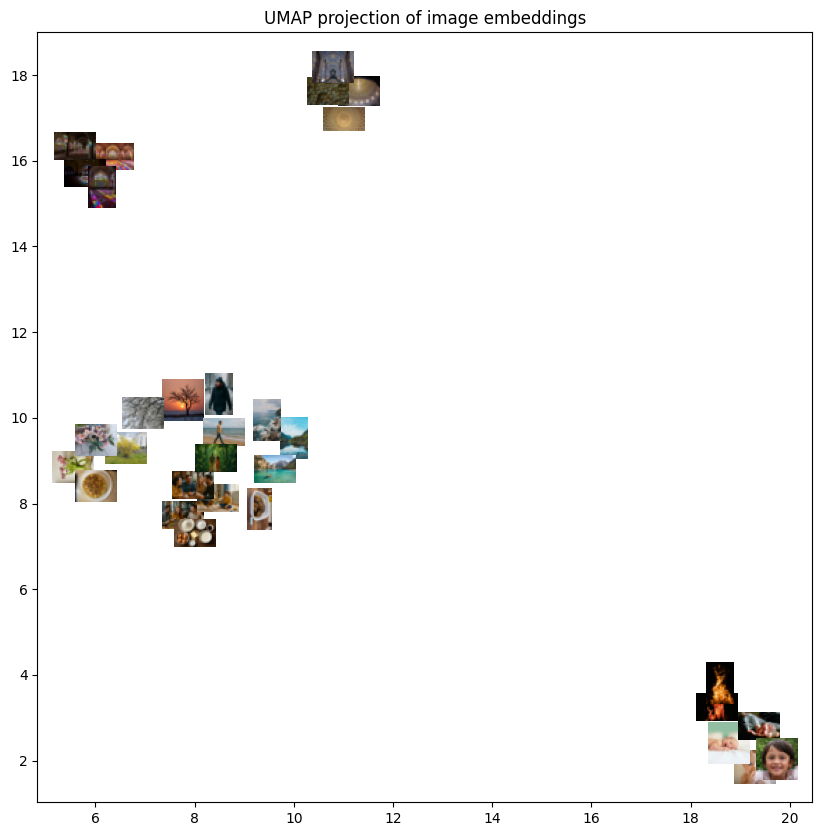

In [29]:
import numpy as np
import umap
import matplotlib.pyplot as plt
from matplotlib.offsetbox import OffsetImage, AnnotationBbox
from qdrant_client import QdrantClient, models
import os 
from PIL import Image

def read_all_vectors(client:QdrantClient, collection_name:str, batch_size:int):
    all_vectors = []
    all_payloads = []
    next_page = None
    while True:
        points,next_page = client.scroll(
            collection_name = collection_name,
            limit = batch_size,
            with_vectors= True,
            with_payload = True,
            offset = next_page
        )
        all_vectors.extend([v.vector for v in points])
        all_payloads.extend([v.payload for v in points])
        if next_page is None:
            break
    return np.array(all_vectors), all_payloads
    
if __name__ == "__main__":
    client = QdrantClient("http://qdrant:6333")
    scrolled_vectors,all_payloads = read_all_vectors(client, collection_name = "test_collection2", batch_size = 33)
    print(f"Retrieved {len(scrolled_vectors)} vectors with shape {scrolled_vectors.shape}")
    reducer = umap.UMAP(n_neighbors=4,min_dist=0.5, metric='cosine',random_state=42)
    embedding_2d = reducer.fit_transform(scrolled_vectors)
    # ##image_path
    # image_name = [p.get('image_filename') for p in all_payloads]
    # image_paths = [os.path.join("./images", name) for name in image_name]
    # ##
    
    # plt.figure(figsize=(8, 8))
    # plt.scatter(embedding_2d[:, 0], embedding_2d[:, 1], s=50, alpha=0.8)
    # plt.title("UMAP visualization of image embeddings")
    # plt.xlabel("UMAP-1")
    # plt.ylabel("UMAP-2")

    image_paths = [p.get('image_path') for p in all_payloads]
    fig, ax = plt.subplots(figsize=(10, 10))
    ax.set_title("UMAP projection of image embeddings")
    for (x, y), img_path in zip(embedding_2d, image_paths):
        try:
            img = Image.open(img_path)
            img.thumbnail((30, 30))
            imagebox = OffsetImage(img, zoom=1)
            ab = AnnotationBbox(imagebox, (x, y), frameon=False)
            ax.add_artist(ab)
        except Exception as e:
            # If image not found or can't be loaded, skip
            print(f"Skipping {img_path}: {e}")
            pass

    ax.update_datalim(embedding_2d)
    ax.autoscale_view()
    plt.show()

# Search

In [5]:
from transformers import AutoProcessor, AutoModelForCausalLM
from huggingface_hub import login
import os

def setup_MLLM_model(huggingface_token:str, model_id:str):
    login(token=huggingface_token)
    print("Loading HuggingFace model and processor...")
    processor = AutoProcessor.from_pretrained(model_id)
    model = AutoModelForCausalLM.from_pretrained(model_id, torch_dtype=torch.bfloat16, device_map="auto")
    return  model, processor
    
if __name__=='__main__':
    HUGGINGFACE_TOKEN =  os.getenv("HUGGINGFACE_TOKEN")
    assert HUGGINGFACE_TOKEN is not None
    MODEL_ID = "google/gemma-3-4b-it"  # Use a Gemma 3 multimodal model
    
    # 1. Setup Models (Configuration)
    gemma_model,gemma_processor = setup_MLLM_model(huggingface_token=HUGGINGFACE_TOKEN,
                                        model_id=MODEL_ID)

Loading HuggingFace model and processor...


Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.
`torch_dtype` is deprecated! Use `dtype` instead!


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

Some parameters are on the meta device because they were offloaded to the disk and cpu.


Collection 'test_collection2' already exists.
{'image_filename': 'omar-lopez-vTknj2OxDVg-unsplash.jpg', 'image_path': './images/omar-lopez-vTknj2OxDVg-unsplash.jpg', 'embeddings_path': './images/omar-lopez-vTknj2OxDVg-unsplash.npy'} 0.04098545
{'image_filename': 'filip-mroz-oko_4WnoM98-unsplash.jpg', 'image_path': './images/filip-mroz-oko_4WnoM98-unsplash.jpg', 'embeddings_path': './images/filip-mroz-oko_4WnoM98-unsplash.npy'} 0.03978901
{'image_filename': 'colin-maynard-CEEhmAGpYzE-unsplash.jpg', 'image_path': './images/colin-maynard-CEEhmAGpYzE-unsplash.jpg', 'embeddings_path': './images/colin-maynard-CEEhmAGpYzE-unsplash.npy'} 0.039560944
{'image_filename': '7.jpeg', 'image_path': './images/7.jpeg', 'embeddings_path': './images/7.npy'} 0.036638033
{'image_filename': 'alice-triquet-HeEJU3nrg_0-unsplash.jpg', 'image_path': './images/alice-triquet-HeEJU3nrg_0-unsplash.jpg', 'embeddings_path': './images/alice-triquet-HeEJU3nrg_0-unsplash.npy'} 0.030517304


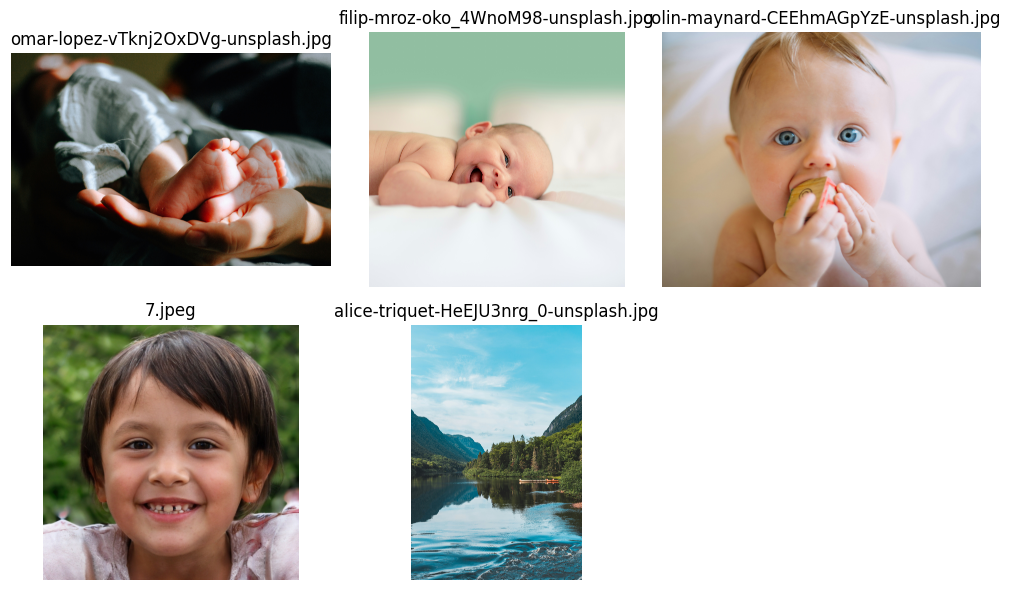

In [31]:
import numpy as np
import torch
from PIL import Image
from abc import ABC, abstractmethod
import math
import  matplotlib.pyplot as plt
import matplotlib.image as mpimg

class Search(ABC):
    def __init__(self, vectordb:EmbeddingsDB):
        self.vectordb = vectordb
    def search_in_vectordb(self):
        pass

# --- 1. Search Based on Live Image ---
class SearchBasedImage(Search):
    def __init__(self, embedding_gen:EmbeddingsGenerator, vectordb:EmbeddingsDB):
        super().__init__(vectordb) 
        self.embedding_gen = embedding_gen
        
    def image_to_embeddings(self, image_path:str):
        """ Generates a multi-vector array from an image file."""
        image = Image.open(image_path)
        query_tensor = self.embedding_gen.get_vision_embeddings(image)
        return query_tensor.detach().cpu().to(torch.float32).numpy()

    def search_in_vectordb(self, image_path:str):
        query= self.image_to_embeddings(image_path)
        # NOTE: mean-pooling across axis=1 (patches dimension)
        # and flattening. This is correct for generating a single dense vector 
        # from a multi-vector array (eg, [1:batch number, N_patches,D_vector]->(D_vector))
        query_vector = np.mean(query, axis=1).flatten()
        hits = self.vectordb.retrieve_embeddings(query_vector, rescore_limit=10,limit=8)
        return hits
        
# --- 2. Search Based on Pre-saved Embeddings File ---
class SearchBasedEmbeddingsfile(Search):
    def __init__(self,vectordb:EmbeddingsDB):
        super().__init__(vectordb) 

    def load_embeddings(self,embeddings_path:str):
        """ Loads the pre-saved vector array (a multi-vector array)."""
        query = np.load(embeddings_path)
        return query
    def search_in_vectordb(self,embeddings_path:str):
        query = self.load_embeddings(embeddings_path)
        query_vector = np.mean(query,axis=1).flatten()
        hits = self.vectordb.retrieve_embeddings(query_vector,rescore_limit=10,limit=8)
        return hits

# --- 3. Search Based on Prompt ---
class SearchBasedPrompt(Search):
    def __init__(self, model:AutoModelForCausalLM, processor:AutoProcessor, vectordb:EmbeddingsDB):
        super().__init__(vectordb) 
        self.model = model
        self.processor = processor
        
    def prompt_to_embeddings (self,prompt:str):
        # this part should transfer to embedding generator class in future#
        # 1. tokenize the prompt
        inputs = self.processor.tokenizer(prompt, return_tensors="pt",padding=True, truncation=True, max_length=512).to(self.model.device) # truncation=True, max_length=512: this means truncate the prompt after 512 tokens
        # 2. Pass tokens through the *full* model to get hidden states
        self.model.eval()
        with torch.no_grad():
            outputs = self.model(**inputs, output_hidden_states=True) ##** unpack the dictionary of inputs which contatinig input_ids, attention_mask, pixel_values
        # 3. Get the last hidden state 
        sentence_embedding = outputs.hidden_states[-1]# Shape: [1, seq_len, 2560]
        return sentence_embedding.detach().cpu().to(torch.float32).numpy()

    def search_in_vectordb(self, prompt:str):
        # 1. text embedding
        query = self.prompt_to_embeddings(prompt)
        query_vector = np.mean(query,axis=1).flatten()
        hits = self.vectordb.retrieve_embeddings(query_vector, rescore_limit=10, limit=5)
        return hits

def show_images(hits):
    destination_paths = [p.payload['image_path'] for p in hits]
    image_filename = [p.payload['image_filename'] for p in hits]
    if not destination_paths:
        print("No image files found to show")
    else:
        # Grid configuration
        num_images = len(destination_paths)
        cols = 3
        rows = math.ceil(num_images / cols) 
        
        # Set figure size (adjust as needed)
        plt.figure(figsize=(10, 3 * rows))
        
        for i, ip in enumerate(destination_paths):
            img = mpimg.imread(ip)
            
            plt.subplot(rows, cols, i + 1)
            plt.imshow(img)
            plt.axis('off')  # Hide axes
            plt.title(image_filename[i])
        
    plt.tight_layout()
    plt.show()     

if __name__ =='__main__':
    EMBEDDINGS_PATH = './test/filip-mroz-oko_4WnoM98-unsplash.npy'
    CLIENT_URL = "http://qdrant:6333"
    COLLECTION_NAME = 'test_collection2'
    VECTOR_DIM= 2560


    # 2. Setup DB (Configuration)
    client = QdrantClient(CLIENT_URL)
    embeddingsdb_instance = EmbeddingsDB(client, COLLECTION_NAME, VECTOR_DIM)
    #3. setup image embeddings generator (configuration)
    gemma_vision_embeddings_generator = EmbeddingsGenerator(gemma_model,gemma_processor)
    
    search_based_propmt = SearchBasedPrompt(model=gemma_model, 
                              processor=gemma_processor,
                              vectordb=embeddingsdb_instance)

    hits = search_based_propmt.search_in_vectordb(prompt='find the picture showing baby')

    # search_based_image = SearchBasedImage(embedding_gen=gemma_vision_mbeddings_generator,vectordb=embeddingsdb_instance)
    # hits = search_based_image.search_in_vectordb(image_path ='./images/7.jpeg')
    
    # search_based_pre_embeddings = SearchBasedEmbeddingsfile(vectordb=embeddingsdb_instance)
    # hits = search_based_pre_embeddings.search_in_vectordb(embeddings_path='./test/filip-mroz-oko_4WnoM98-unsplash.npy')

    show_images(hits)